<a href="https://colab.research.google.com/github/Amasha09/predicting_accident_risk/blob/main/accident_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import kagglehub
path = kagglehub.dataset_download("ianktoo/simulated-roads-accident-data")

100%|██████████| 1.01M/1.01M [00:00<00:00, 59.2MB/s]

Extracting files...


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
import os

df1 = pd.read_csv(os.path.join(path, "synthetic_road_accidents_2k.csv"))
df2 = pd.read_csv(os.path.join(path, "synthetic_road_accidents_10k.csv"))
df3 = pd.read_csv(os.path.join(path, "synthetic_road_accidents_100k.csv"))


In [ ]:
_df = pd.concat([df1, df2, df3])
print(_df.shape)

(112000, 13)


In [ ]:
#Final combined dataframe
_df = _df.drop_duplicates()
print(f"Number of duplicates after removal: {_df.duplicated().sum()}")
print(f"Shape of the df after removal: {_df.shape}")


Number of duplicates after removal: 0
Shape of the df after removal: (111961, 13)


In [ ]:
#final_df with corrected column indexes.
_df.reset_index(drop = True, inplace = True)
print(_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111961 entries, 0 to 111960
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               111961 non-null  object 
 1   num_lanes               111961 non-null  int64  
 2   curvature               111961 non-null  float64
 3   speed_limit             111961 non-null  int64  
 4   lighting                111961 non-null  object 
 5   weather                 111961 non-null  object 
 6   road_signs_present      111961 non-null  bool   
 7   public_road             111961 non-null  bool   
 8   time_of_day             111961 non-null  object 
 9   holiday                 111961 non-null  bool   
 10  school_season           111961 non-null  bool   
 11  num_reported_accidents  111961 non-null  int64  
 12  accident_risk           111961 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 8.1+ MB
None


In [ ]:
_df_copy = _df.copy()

In [ ]:

X = _df_copy.drop(["accident_risk","num_reported_accidents"], axis = 1)
y = _df_copy["accident_risk"]

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
f_df = pd.concat([X_train, y_train], axis = 1)
print(f_df.shape)

(78372, 12)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
df_train = f_df.copy()

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78372 entries, 80965 to 15795
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   road_type           78372 non-null  object 
 1   num_lanes           78372 non-null  int64  
 2   curvature           78372 non-null  float64
 3   speed_limit         78372 non-null  int64  
 4   lighting            78372 non-null  object 
 5   weather             78372 non-null  object 
 6   road_signs_present  78372 non-null  bool   
 7   public_road         78372 non-null  bool   
 8   time_of_day         78372 non-null  object 
 9   holiday             78372 non-null  bool   
 10  school_season       78372 non-null  bool   
 11  accident_risk       78372 non-null  float64
dtypes: bool(4), float64(2), int64(2), object(4)
memory usage: 5.7+ MB


In [ ]:
cat_cols = X.select_dtypes(include = ["object","category"]).columns
num_cols = X.select_dtypes(exclude = ["object","category","bool"]).columns
bool_cols = X.select_dtypes(include = "bool").columns
num_cols, cat_cols, bool_cols

(Index(['num_lanes', 'curvature', 'speed_limit'], dtype='object'),
 Index(['road_type', 'lighting', 'weather', 'time_of_day'], dtype='object'),
 Index(['road_signs_present', 'public_road', 'holiday', 'school_season'], dtype='object'))

In [ ]:
X_train["high_speed"] = (X_train["speed_limit"] > 45).astype(bool)

In [ ]:
X_test["high_speed"] = (X_test["speed_limit"] > 45).astype(bool)

In [ ]:
X_train = X_train.drop("speed_limit", axis = 1)

In [ ]:
X_test = X_test.drop("speed_limit", axis = 1)

In [ ]:
X_train.head(20)

,road_type,num_lanes,curvature,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,high_speed
80965,rural,2,0.69,daylight,clear,True,True,afternoon,False,True,False
73776,urban,1,0.97,night,clear,False,True,morning,False,True,False
22848,highway,3,0.31,dim,foggy,False,True,morning,True,False,False
31456,highway,3,0.74,night,clear,True,False,afternoon,True,False,False
19772,urban,3,0.86,daylight,rainy,True,False,afternoon,True,False,True
77587,urban,3,0.57,night,rainy,False,True,morning,True,False,False
64063,urban,3,0.95,dim,rainy,False,False,morning,True,True,True
66122,urban,2,0.97,dim,rainy,False,True,afternoon,True,True,True
92821,highway,2,0.48,daylight,foggy,False,True,afternoon,True,False,False
32240,urban,3,0.80,dim,rainy,False,True,evening,False,True,False


In [ ]:
X_test.head(10)

,road_type,num_lanes,curvature,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,high_speed
33810,rural,2,0.12,daylight,foggy,True,False,evening,True,False,False
3113,rural,3,0.43,daylight,foggy,True,True,afternoon,False,True,False
94163,urban,3,0.57,dim,clear,True,True,afternoon,False,False,True
73431,highway,1,0.94,daylight,rainy,True,False,afternoon,True,False,True
59343,rural,4,0.77,daylight,clear,True,False,morning,True,False,True
66687,highway,2,0.75,daylight,clear,False,True,morning,True,False,False
63834,urban,1,0.24,daylight,rainy,True,True,morning,False,False,False
46956,urban,4,0.36,dim,rainy,True,False,evening,True,False,False
48891,rural,3,0.12,dim,foggy,False,True,morning,False,False,True
48076,highway,2,0.26,daylight,clear,True,False,afternoon,False,False,False


In [ ]:
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

# Define the columns to drop based on the requested reference categories
drop_cols = [
    'road_type_urban',
    'lighting_daylight',
    'weather_clear',
    'road_signs_present_True',
    'public_road_True',
    'time_of_day_morning',
    'holiday_False',
    'school_season_True',
    'high_speed_False'
]

# Drop the specified reference categories from both train and test sets
X_train_enc = X_train_enc.drop(columns=[col for col in drop_cols if col in X_train_enc.columns])
X_test_enc = X_test_enc.drop(columns=[col for col in drop_cols if col in X_test_enc.columns])

X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc,
    join="left",  # keep all columns from X_train
    axis=1,
    fill_value=0  # missing columns in X_test → fill with 0
)


In [ ]:
X_train_enc.head(10)

,num_lanes,curvature,road_signs_present,public_road,holiday,school_season,high_speed,road_type_highway,road_type_rural,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_afternoon,time_of_day_evening
80965,2,0.69,True,True,False,True,False,False,True,False,False,False,False,True,False
73776,1,0.97,False,True,False,True,False,False,False,False,True,False,False,False,False
22848,3,0.31,False,True,True,False,False,True,False,True,False,True,False,False,False
31456,3,0.74,True,False,True,False,False,True,False,False,True,False,False,True,False
19772,3,0.86,True,False,True,False,True,False,False,False,False,False,True,True,False
77587,3,0.57,False,True,True,False,False,False,False,False,True,False,True,False,False
64063,3,0.95,False,False,True,True,True,False,False,True,False,False,True,False,False
66122,2,0.97,False,True,True,True,True,False,False,True,False,False,True,True,False
92821,2,0.48,False,True,True,False,False,True,False,False,False,True,False,True,False
32240,3,0.80,False,True,False,True,False,False,False,True,False,False,True,False,True


In [ ]:
X_train_enc.select_dtypes(include=["int","float"])


,num_lanes,curvature
80965,2,0.69
73776,1,0.97
22848,3,0.31
31456,3,0.74
19772,3,0.86
...,...,...
76820,1,0.76
110268,2,0.51
103694,4,0.57
860,1,0.55


In [ ]:
print(X_train.columns.tolist())


['road_type', 'num_lanes', 'curvature', 'lighting', 'weather', 'road_signs_present', 'public_road', 'time_of_day', 'holiday', 'school_season', 'high_speed']


In [ ]:
X_train_enc.shape, X_test_enc.shape


((78372, 15), (33589, 15))

In [ ]:
X_train_enc.isnull().sum().sum(), X_test_enc.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [ ]:
X_train_enc.select_dtypes(include="object")


""
80965
73776
22848
31456
19772
...
76820
110268
103694
860


In [ ]:
X_train_enc.dtypes


,0
num_lanes,int64
curvature,float64
road_signs_present,bool
public_road,bool
holiday,bool
school_season,bool
high_speed,bool
road_type_highway,bool
road_type_rural,bool
lighting_dim,bool


#Linear Regression

**We first fit a linear regression model as a base line model before moving into advanced models***

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_enc, y_train)

y_pred_lr = lr.predict(X_test_enc)
y_pred_lr_train = lr.predict(X_train_enc)

y_pred_lr = np.maximum(y_pred_lr, 0)
y_pred_lr_train = np.maximum(y_pred_lr_train, 0)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

mae_lr_tr = mean_absolute_error(y_train, y_pred_lr_train)
rmse_lr_tr = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
r2_lr_tr = r2_score(y_train, y_pred_lr_train)

print(f"Linear Regression MAE: {mae_lr:.5f}")
print(f"Linear Regression RMSE: {rmse_lr:.5f}")
print(f"Linear Regression R2 Score: {r2_lr:.5f}")

print(f"Linear Regression MAE: {mae_lr_tr:.5f}")
print(f"Linear Regression RMSE: {rmse_lr_tr:.5f}")
print(f"Linear Regression R2 Score: {r2_lr_tr:.5f}")

Linear Regression MAE: 0.05022
Linear Regression RMSE: 0.06320
Linear Regression R2 Score: 0.87402
Linear Regression MAE: 0.05039
Linear Regression RMSE: 0.06349
Linear Regression R2 Score: 0.87480


In [ ]:
import pandas as pd

lr_metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Train': [mae_lr_tr, rmse_lr_tr, r2_lr_tr],
    'Test': [mae_lr, rmse_lr, r2_lr]
})

print("Linear Regression Metrics:")
display(lr_metrics_table)

Linear Regression Metrics:


,Metric,Train,Test
0,MAE,0.050388,0.050216
1,RMSE,0.063489,0.063199
2,R2 Score,0.874799,0.874016


**Residual Analysis for the regression model**

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

residuals = y_test - y_pred_lr


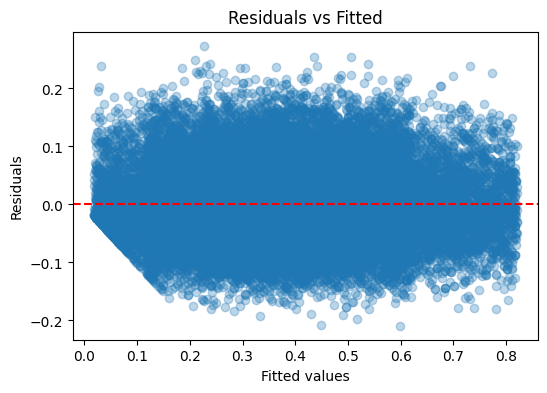

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


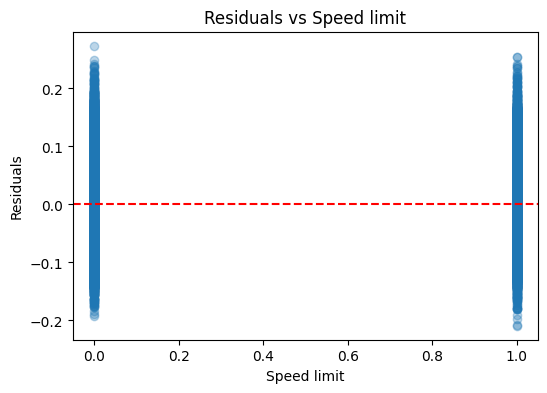

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_test["high_speed"], residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Speed limit")
plt.ylabel("Residuals")
plt.title("Residuals vs Speed limit")
plt.show()


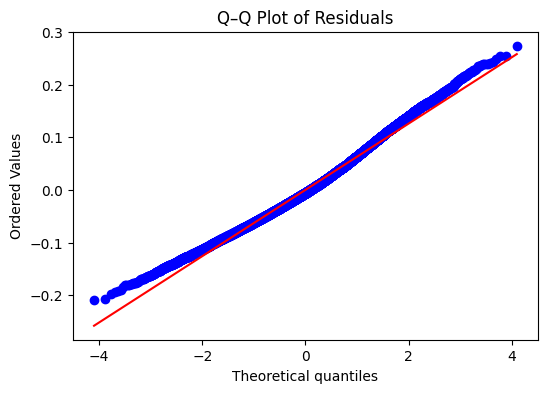

In [ ]:
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals")
plt.show()


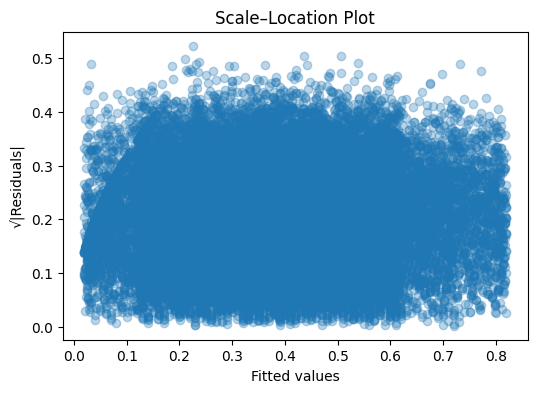

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, np.sqrt(np.abs(residuals)), alpha=0.3)
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale–Location Plot")
plt.show()


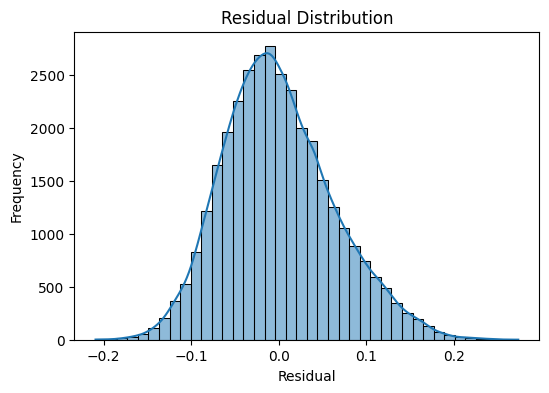

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=40, kde=True)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

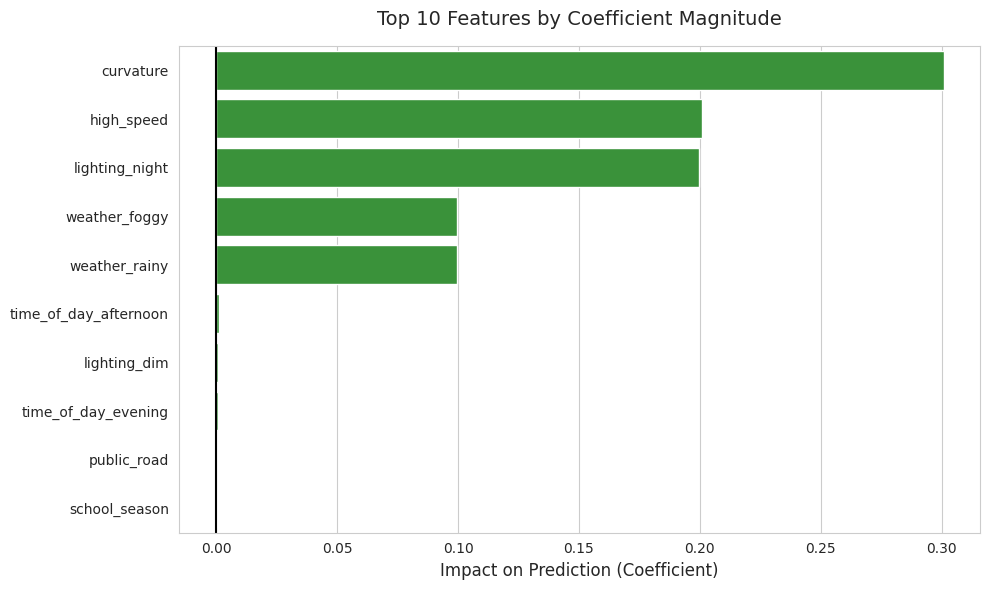

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare Data (Top 10 features)
coef_df = pd.DataFrame({
    "feature": X_train_enc.columns,
    "coef": lr.coef_.flatten() # flatten() handles dimensions safely
}).assign(abs_coef=lambda d: d.coef.abs()) \
  .sort_values("abs_coef", ascending=False).head(10)

# Add a boolean column for coloring
coef_df['is_positive_coef'] = coef_df['coef'] >= 0

# 2. Create a "Better" Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create barplot with custom colors (Green = Positive impact, Red = Negative impact)
plot = sns.barplot(
    data=coef_df,
    x="coef",
    y="feature",
    hue="is_positive_coef", # Assign hue to the boolean column
    palette={True: "#2ca02c", False: "#d62728"}, # Provide a dictionary for palette
    legend=False
)

# 3. Formatting
plt.title("Top 10 Features by Coefficient Magnitude", fontsize=14, pad=15)
plt.xlabel("Impact on Prediction (Coefficient)", fontsize=12)
plt.ylabel("")
plt.axvline(x=0, color='black', linewidth=1.5) # Add a strong vertical line at 0

plt.tight_layout()
plt.show()

#Multicollinearity for the linear model.

In [ ]:
import pandas as pd
import numpy as np

def calculate_gvif(X, feature_groups):
    corr_matrix = X.corr()

    gvif_data = []

    for feature_name, columns in feature_groups.items():
        valid_cols = [c for c in columns if c in X.columns]
        if not valid_cols:
            continue

        cols_group = valid_cols
        cols_rest = [c for c in X.columns if c not in valid_cols]

        det_R = np.linalg.det(corr_matrix)

        det_R_group = np.linalg.det(corr_matrix.loc[cols_group, cols_group])

        det_R_rest = np.linalg.det(corr_matrix.loc[cols_rest, cols_rest])

        gvif = (det_R_group * det_R_rest) / (det_R + 1e-10)

        df = len(cols_group)
        adjusted_gvif = np.power(gvif, 1 / (2 * df))

        gvif_data.append({
            "Feature": feature_name,
            "GVIF": gvif,
            "GVIF^(1/2*df)": adjusted_gvif,
            "df": df
        })

    return pd.DataFrame(gvif_data).sort_values("GVIF", ascending=False)


X_vif = X_train_enc.copy()
for col in X_vif.select_dtypes(include=['bool']).columns:
    X_vif[col] = X_vif[col].astype(int)

feature_groups = {}

for col in X_vif.columns:
    if "_" in col:
        prefix = col.rsplit("_", 1)[0]
    else:
        prefix = col

    if prefix not in feature_groups:
        feature_groups[prefix] = []
    feature_groups[prefix].append(col)

gvif_df = calculate_gvif(X_vif, feature_groups)

print(gvif_df)

        Feature      GVIF  GVIF^(1/2*df)  df
7     road_type  1.000514       1.000129   2
10  time_of_day  1.000297       1.000074   2
2    road_signs  1.000270       1.000135   1
9       weather  1.000259       1.000065   2
3        public  1.000241       1.000121   1
8      lighting  1.000233       1.000058   2
4       holiday  1.000216       1.000108   1
0           num  1.000173       1.000087   1
1     curvature  1.000124       1.000062   1
5        school  1.000116       1.000058   1
6          high  1.000092       1.000046   1


In [ ]:


pd.DataFrame({
    "residual": residuals,
    "high_speed": X_test_enc["high_speed"]
}).groupby("high_speed").describe()


residual                                                    \
              count      mean       std       min       25%       50%   
high_speed                                                              
False       20155.0  0.000638  0.062942 -0.193061 -0.043540 -0.005228   
True        13434.0 -0.001235  0.063570 -0.209177 -0.046098 -0.006787   

                                
                 75%       max  
high_speed                      
False       0.040253  0.273621  
True        0.038165  0.253683

<Axes: xlabel='accident_risk', ylabel='Count'>

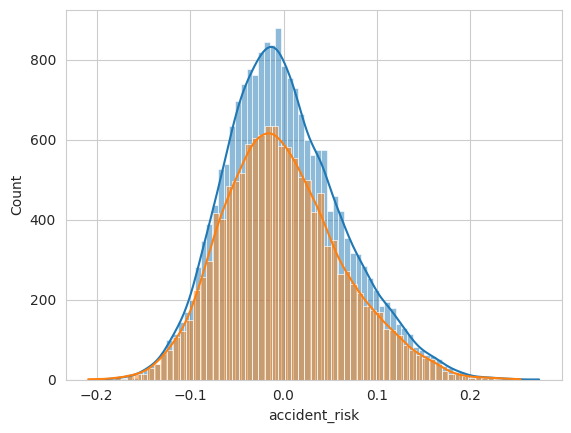

In [ ]:
sns.histplot(residuals[X_test_enc["high_speed"] == 0], label="low speed", kde=True)
sns.histplot(residuals[X_test_enc["high_speed"] == 1], label="high speed", kde=True)


In [ ]:
X_train_enc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78372 entries, 80965 to 15795
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_lanes              78372 non-null  int64  
 1   curvature              78372 non-null  float64
 2   road_signs_present     78372 non-null  bool   
 3   public_road            78372 non-null  bool   
 4   holiday                78372 non-null  bool   
 5   school_season          78372 non-null  bool   
 6   high_speed             78372 non-null  bool   
 7   road_type_highway      78372 non-null  bool   
 8   road_type_rural        78372 non-null  bool   
 9   lighting_dim           78372 non-null  bool   
 10  lighting_night         78372 non-null  bool   
 11  weather_foggy          78372 non-null  bool   
 12  weather_rainy          78372 non-null  bool   
 13  time_of_day_afternoon  78372 non-null  bool   
 14  time_of_day_evening    78372 non-null  bool   
dtypes: 

In [ ]:
X_train_enc.head(10)

,num_lanes,curvature,road_signs_present,public_road,holiday,school_season,high_speed,road_type_highway,road_type_rural,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_afternoon,time_of_day_evening
80965,2,0.69,True,True,False,True,False,False,True,False,False,False,False,True,False
73776,1,0.97,False,True,False,True,False,False,False,False,True,False,False,False,False
22848,3,0.31,False,True,True,False,False,True,False,True,False,True,False,False,False
31456,3,0.74,True,False,True,False,False,True,False,False,True,False,False,True,False
19772,3,0.86,True,False,True,False,True,False,False,False,False,False,True,True,False
77587,3,0.57,False,True,True,False,False,False,False,False,True,False,True,False,False
64063,3,0.95,False,False,True,True,True,False,False,True,False,False,True,False,False
66122,2,0.97,False,True,True,True,True,False,False,True,False,False,True,True,False
92821,2,0.48,False,True,True,False,False,True,False,False,False,True,False,True,False
32240,3,0.80,False,True,False,True,False,False,False,True,False,False,True,False,True


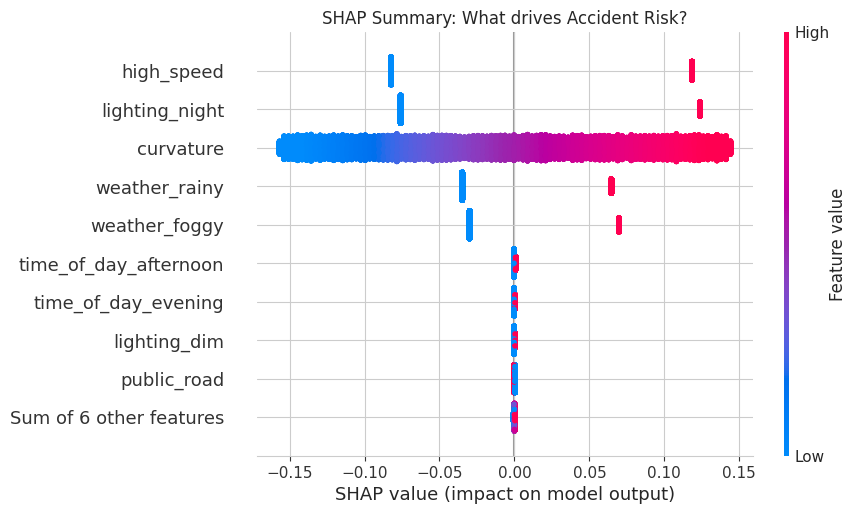

In [ ]:
import shap
import matplotlib.pyplot as plt

# --- THE FIX: Convert data to simple floats ---
# SHAP sometimes crashes on Booleans or Sparse matrices.
# We create temporary variables just for the SHAP calculator.
X_train_shap = X_train_enc.astype(float)
X_test_shap = X_test_enc.astype(float)

# 1. Initialize the Explainer
# Use the new float data
explainer = shap.LinearExplainer(lr, X_train_shap)

# 2. Calculate SHAP values
shap_values = explainer(X_test_shap)

# 3. Plot
plt.figure()
plt.title("SHAP Summary: What drives Accident Risk?")
shap.plots.beeswarm(shap_values, max_display=10)

In [ ]:
X_train_enc_int = X_train_enc.copy()
X_test_enc_int = X_test_enc.copy()

In [ ]:
X_train_enc_int["rain_holiday"] = X_train_enc_int["weather_rainy"] * X_train_enc_int["holiday"]
X_train_enc_int["rain_school"] = X_train_enc_int["weather_rainy"] * X_train_enc_int["holiday"]

In [ ]:
X_test_enc_int["rain_holiday"] = X_test_enc_int["weather_rainy"] * X_test_enc_int["holiday"]
X_test_enc_int["rain_school"] = X_test_enc_int["weather_rainy"] * X_test_enc_int["holiday"]

#Linear Regression with interaction terms

In [ ]:

lr_int = LinearRegression()
lr_int.fit(X_train_enc_int, y_train)

y_pred_lr_int = lr_int.predict(X_test_enc_int)
y_pred_lr_int = np.maximum(y_pred_lr_int, 0)

mae_lr_int = mean_absolute_error(y_test, y_pred_lr_int)
rmse_lr_int = np.sqrt(mean_squared_error(y_test, y_pred_lr_int))
r2_lr_int = r2_score(y_test, y_pred_lr_int)

y_pred_lr_int_train = lr_int.predict(X_train_enc_int)
y_pred_lr_int_train = np.maximum(y_pred_lr_int_train, 0)

mae_lr_int_train = mean_absolute_error(y_train, y_pred_lr_int_train)
rmse_lr_int_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_int_train))
r2_lr_int_train = r2_score(y_train, y_pred_lr_int_train)

print(f"Linear Regression with Interactions Test MAE: {mae_lr_int:.5f}")
print(f"Linear Regression with Interactions Test RMSE: {rmse_lr_int:.5f}")
print(f"Linear Regression with Interactions Test R2 Score: {r2_lr_int:.5f}")

print(f"Linear Regression with Interactions Train MAE: {mae_lr_int_train:.5f}")
print(f"Linear Regression with Interactions Train RMSE: {rmse_lr_int_train:.5f}")
print(f"Linear Regression with Interactions Train R2 Score: {r2_lr_int_train:.5f}")

Linear Regression with Interactions Test MAE: 0.05022
Linear Regression with Interactions Test RMSE: 0.06320
Linear Regression with Interactions Test R2 Score: 0.87401
Linear Regression with Interactions Train MAE: 0.05039
Linear Regression with Interactions Train RMSE: 0.06349
Linear Regression with Interactions Train R2 Score: 0.87480


In [ ]:
import pandas as pd

lr_int_metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Train': [mae_lr_int_train, rmse_lr_int_train, r2_lr_int_train],
    'Test': [mae_lr_int, rmse_lr_int, r2_lr_int]
})

print("Linear Regression with Interactions Metrics:")
display(lr_int_metrics_table)

Linear Regression with Interactions Metrics:


,Metric,Train,Test
0,MAE,0.050388,0.050216
1,RMSE,0.063489,0.063199
2,R2 Score,0.874799,0.874013


In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

residuals_int = y_test - y_pred_lr_int

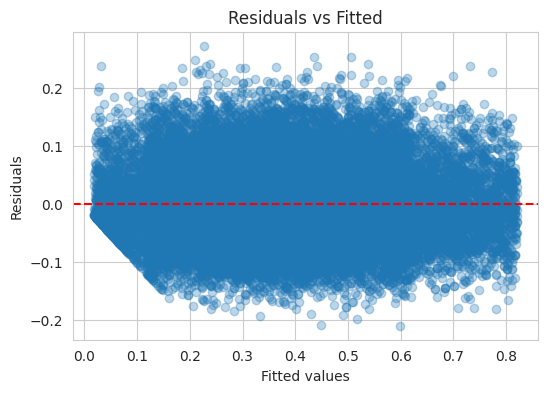

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr_int, residuals_int, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


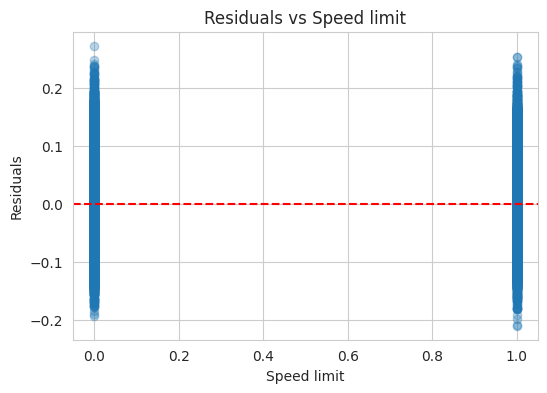

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_test_enc["high_speed"], residuals_int, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Speed limit")
plt.ylabel("Residuals")
plt.title("Residuals vs Speed limit")
plt.show()


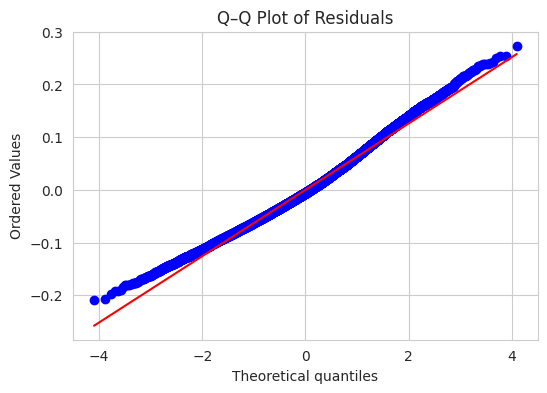

In [ ]:
plt.figure(figsize=(6,4))
stats.probplot(residuals_int, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals")
plt.show()


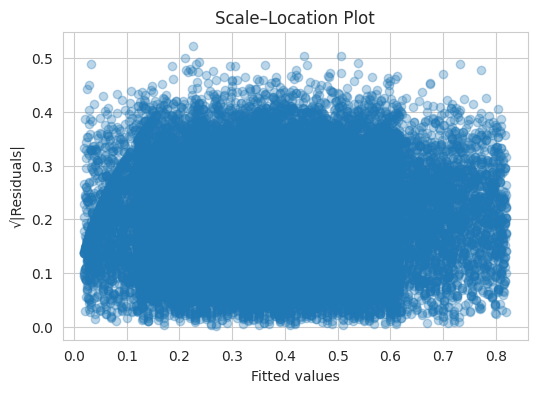

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr_int, np.sqrt(np.abs(residuals_int)), alpha=0.3)
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale–Location Plot")
plt.show()


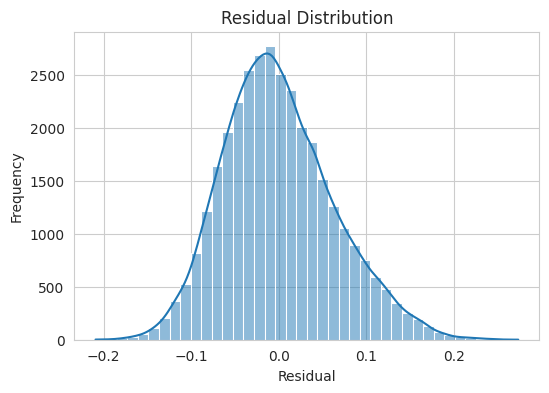

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(residuals_int, bins=40, kde=True)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

In [ ]:
import pandas as pd

lr_metrics = {
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Value': [mae_lr, rmse_lr, r2_lr],
    'Linear with interaction': [mae_lr_int, rmse_lr_int, r2_lr_int],
}
lr_metrics_df = pd.DataFrame(lr_metrics)
print(lr_metrics_df)


     Metric  Linear Value  Linear with interaction
0       MAE      0.050216                 0.050216
1      RMSE      0.063199                 0.063199
2  R2 Score      0.874016                 0.874013


#Lasso Regression

**Since we don't have a multicollinearity problem and from the eda we found some features to not have much of an influence on the accident_risk, we are trying lasso regression**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV


In [ ]:
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        alphas=None,
        cv=5,
        max_iter=10000,
        random_state=42
    ))
])

lasso.fit(X_train_enc, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', LassoCV(cv=5, max_iter=10000, random_state=42))])

In [ ]:
y_pred_lasso = lasso.predict(X_test_enc)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

y_pred_lasso_train = lasso.predict(X_train_enc)

mae_lasso_train = mean_absolute_error(y_train, y_pred_lasso_train)
rmse_lasso_train = np.sqrt(mean_squared_error(y_train, y_pred_lasso_train))
r2_lasso_train = r2_score(y_train, y_pred_lasso_train)

print(f"Lasso Test MAE: {mae_lasso:.5f}")
print(f"Lasso Test RMSE: {rmse_lasso:.5f}")
print(f"Lasso Test R2 Score: {r2_lasso:.5f}")

print(f"\nLasso Train MAE: {mae_lasso_train:.5f}")
print(f"Lasso Train RMSE: {rmse_lasso_train:.5f}")
print(f"Lasso Train R2 Score: {r2_lasso_train:.5f}")

Lasso Test MAE: 0.05021
Lasso Test RMSE: 0.06320
Lasso Test R2 Score: 0.87401

Lasso Train MAE: 0.05040
Lasso Train RMSE: 0.06349
Lasso Train R2 Score: 0.87478


In [ ]:
best_alpha = lasso.named_steps["lasso"].alpha_
print("Best alpha:", best_alpha)


Best alpha: 0.00021197875397736438


In [ ]:
import pandas as pd

lasso_metrics = {
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Lasso Value': [mae_lasso, rmse_lasso, r2_lasso],
    'Linear Value': [mae_lr, rmse_lr, r2_lr],
    'Linear Value with interactions': [mae_lr_int, rmse_lr_int, r2_lr_int]
}
lasso_metrics_df = pd.DataFrame(lasso_metrics)
print(lasso_metrics_df.to_markdown(index=False))

| Metric   |   Lasso Value |   Linear Value |   Linear Value with interactions |
|:---------|--------------:|---------------:|---------------------------------:|
| MAE      |     0.0502144 |      0.0502157 |                        0.0502164 |
| RMSE     |     0.0631991 |      0.0631988 |                        0.0631994 |
| R2 Score |     0.874014  |      0.874016  |                        0.874013  |


In [ ]:
coef = lasso.named_steps["lasso"].coef_
feature_names = X_train_enc.columns

selected = feature_names[coef != 0]
len(selected), selected


(7,
 Index(['curvature', 'public_road', 'high_speed', 'lighting_night',
        'weather_foggy', 'weather_rainy', 'time_of_day_afternoon'],
       dtype='object'))

In [ ]:
lasso_coefs = lasso.named_steps["lasso"].coef_


In [ ]:
import pandas as pd

lasso_feature_names = [
    'num_lanes', 'curvature', 'road_signs_present', 'public_road', 'holiday',
    'school_season', 'high_speed', 'road_type_highway', 'road_type_rural',
    'lighting_dim', 'lighting_night', 'weather_foggy', 'weather_rainy',
    'time_of_day_afternoon', 'time_of_day_evening'
]

linear_int_feature_names = X_train_enc_int.columns.tolist()

lasso_coefs_series = pd.Series(lasso.named_steps["lasso"].coef_, index=lasso_feature_names)

aligned_lasso_coefs = lasso_coefs_series.reindex(linear_int_feature_names, fill_value=0).values

coef_df = pd.DataFrame({
    "Feature": linear_int_feature_names,
    "Linear": lr_int.coef_,
    "Lasso": aligned_lasso_coefs
})

coef_df["abs_Lasso"] = coef_df["Lasso"].abs()
coef_df = coef_df.sort_values(by="abs_Lasso", ascending=False)
coef_df.drop(columns="abs_Lasso", inplace=True)
coef_df

,Feature,Linear,Lasso
6,high_speed,0.200802,0.098238
10,lighting_night,0.199705,0.093825
1,curvature,0.300850,0.086533
11,weather_foggy,0.099644,0.046540
12,weather_rainy,0.099719,0.046361
13,time_of_day_afternoon,0.000930,0.000091
3,public_road,-0.000492,-0.000037
0,num_lanes,0.000175,0.000000
2,road_signs_present,-0.000039,-0.000000
8,road_type_rural,-0.000003,0.000000


In [ ]:
metrics_df = pd.DataFrame({
    "Model": ["Linear Regression","Linear Regression (interactions)", "Lasso Regression (Interactions)"],
    "MAE": [mae_lr,mae_lr_int, mae_lasso],
    "RMSE": [rmse_lr,rmse_lr_int, rmse_lasso],
    "R2 Score": [r2_lr,r2_lr_int, r2_lasso]
})
print("📊 Model Performance Metrics:")
display(metrics_df)

📊 Model Performance Metrics:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.050216,0.063199,0.874016
1,Linear Regression (interactions),0.050216,0.063199,0.874013
2,Lasso Regression (Interactions),0.050214,0.063199,0.874014


In [ ]:
lasso_coefs = lasso.named_steps["lasso"].coef_
selected_mask = lasso_coefs != 0
selected_features = X_train_enc.columns[selected_mask]
selected_values = lasso_coefs[selected_mask]

lasso_table = pd.DataFrame({
    "Feature": selected_features,
    "Lasso Coef": selected_values
}).sort_values(by="Lasso Coef", key=abs, ascending=False)

print("📊 Lasso-selected Features and Coefficients:")
display(lasso_table)

📊 Lasso-selected Features and Coefficients:


,Feature,Lasso Coef
2,high_speed,0.098238
3,lighting_night,0.093825
0,curvature,0.086533
4,weather_foggy,0.046540
5,weather_rainy,0.046361
6,time_of_day_afternoon,0.000091
1,public_road,-0.000037


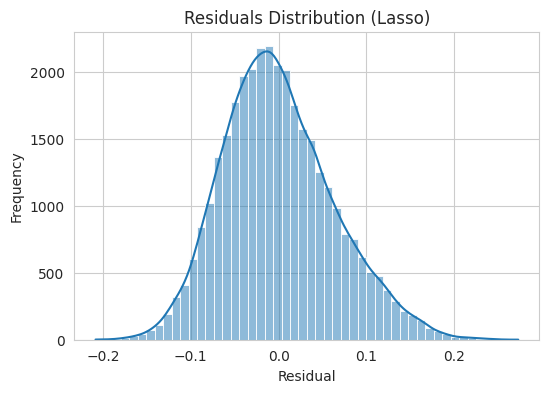

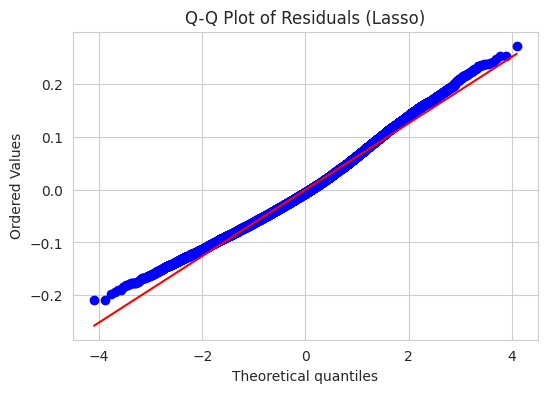

📝 Interpretation Summary:
- Lasso shrunk irrelevant features and interactions to zero, keeping 7 significant predictors.
- Strong predictors include curvature, high_speed, lighting at night, and adverse weather conditions (foggy/rainy).
- Weak interactions such as rain_holiday, rain_school were dropped.
- Metrics (MAE, RMSE, R²) show model explains ~87% of variance in accident risk.
- Residuals are roughly normal, suggesting linear assumptions are reasonable.


In [ ]:
residuals_lasso = y_test - y_pred_lasso

plt.figure(figsize=(6,4))
sns.histplot(residuals_lasso, kde=True, bins=50)
plt.title("Residuals Distribution (Lasso)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
stats.probplot(residuals_lasso, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals (Lasso)")
plt.show()

print("📝 Interpretation Summary:")
print(f"- Lasso shrunk irrelevant features and interactions to zero, keeping {len(selected_features)} significant predictors.")
print("- Strong predictors include curvature, high_speed, lighting at night, and adverse weather conditions (foggy/rainy).")
print("- Weak interactions such as rain_holiday, rain_school were dropped.")
print("- Metrics (MAE, RMSE, R²) show model explains ~87% of variance in accident risk.")
print("- Residuals are roughly normal, suggesting linear assumptions are reasonable.")

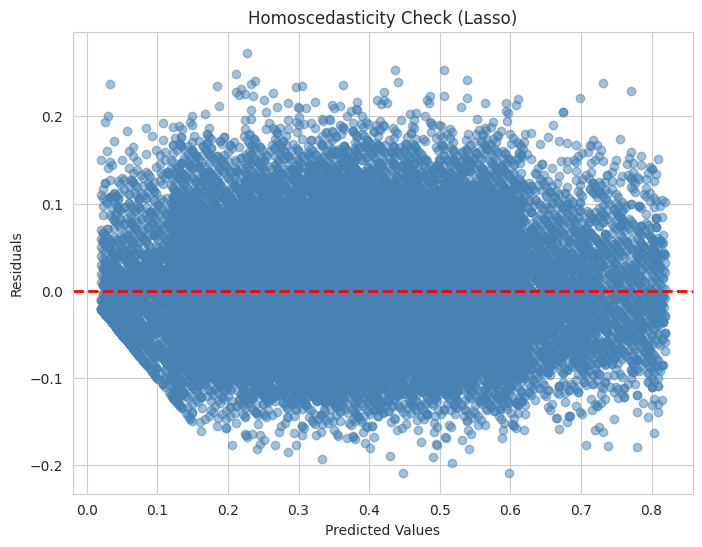

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_lasso, residuals_lasso, alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check (Lasso)")
plt.show()

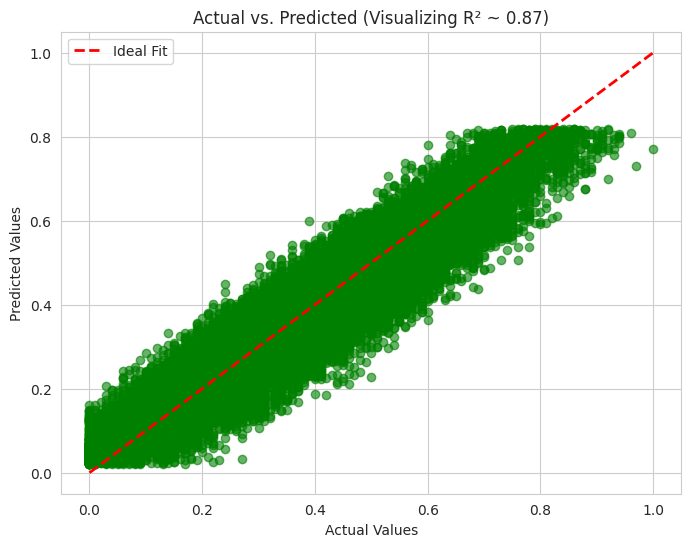

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lasso, alpha=0.6, color='green')

min_val = min(y_test.min(), y_pred_lasso.min())
max_val = max(y_test.max(), y_pred_lasso.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Fit')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted (Visualizing R² ~ 0.87)")
plt.legend()
plt.show()

In [ ]:
interaction_cols = [c for c in X_train_enc.columns if "rain_" in c or "curvature_" in c]
interactions_selected = [c for c in interaction_cols if c in selected_features]
interactions_removed = [c for c in interaction_cols if c not in selected_features]

print("📝 Interactions Summary:")
print(f"- Interactions kept in Lasso: {interactions_selected}")
print(f"- Interactions removed by Lasso: {interactions_removed}")


📝 Interactions Summary:
- Interactions kept in Lasso: []
- Interactions removed by Lasso: []


In [ ]:
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

selected_counts = pd.Series(0, index=X_train_enc.columns)

optimal_alpha = lasso.named_steps["lasso"].alpha_

for train_idx, val_idx in rkf.split(X_train_enc):
    X_tr, X_val = X_train_enc.iloc[train_idx], X_train_enc.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    lasso_model_in_loop = Lasso(alpha=optimal_alpha)
    lasso_model_in_loop.fit(X_tr_s, y_tr)

    selected_counts += (lasso_model_in_loop.coef_ != 0)

display(selected_counts.sort_values(ascending=False).to_frame(name='Selection Count'))

,Selection Count
curvature,50
high_speed,50
lighting_night,50
weather_foggy,50
weather_rainy,50
time_of_day_afternoon,41
public_road,29
num_lanes,22
school_season,11
time_of_day_evening,8


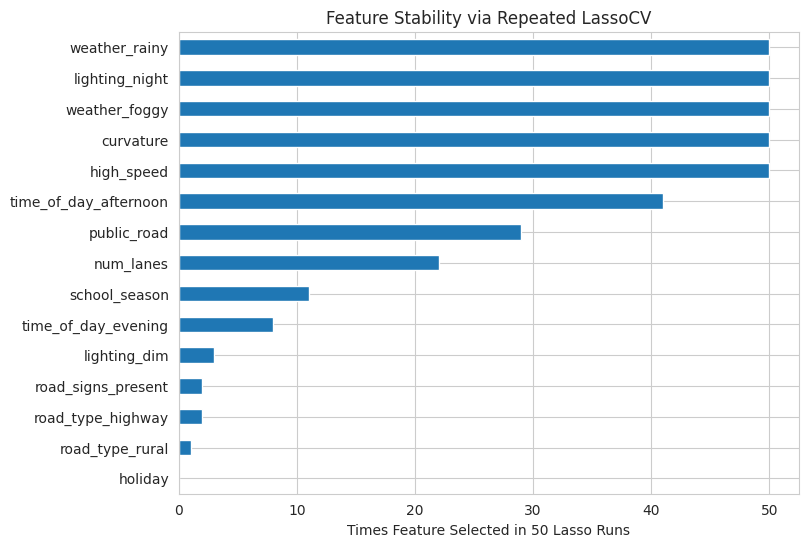

In [ ]:
import matplotlib.pyplot as plt

selected_counts.sort_values(ascending=True).plot(kind="barh", figsize=(8,6))
plt.xlabel("Times Feature Selected in 50 Lasso Runs")
plt.title("Feature Stability via Repeated LassoCV")
plt.show()

**Repeated LassoCV was used to assess feature stability. curvature, high_speed, lighting_night, weather_rainy, and weather_foggy were selected in all 50 splits, making them robust predictors. Features like time_of_day_morning and public_road were sometimes selected, indicating weaker contributions. Interactions such as rain_holiday and rain_school were almost never selected, suggesting they do not improve predictive power.**

#Ridge Regression

In [ ]:
X_train_r = X_train_enc.copy()
X_test_r = X_test_enc.copy()

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]))
])

ridge_pipeline.fit(X_train_r, y_train)

y_pred_ridge = ridge_pipeline.predict(X_test_r)

r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

y_pred_ridge_train = ridge_pipeline.predict(X_train_r)

r2_ridge_train = r2_score(y_train, y_pred_ridge_train)
mae_ridge_train = mean_absolute_error(y_train, y_pred_ridge_train)
rmse_ridge_train = np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))

print(f"Ridge Test R2:   {r2_ridge:.5f}")
print(f"Ridge Test MAE:  {mae_ridge:.5f}")
print(f"Ridge Test RMSE: {rmse_ridge:.5f}")

print(f"\nRidge Train R2:   {r2_ridge_train:.5f}")
print(f"Ridge Train MAE:  {mae_ridge_train:.5f}")
print(f"Ridge Train RMSE: {rmse_ridge_train:.5f}")

Ridge Test R2:   0.87402
Ridge Test MAE:  0.05022
Ridge Test RMSE: 0.06320

Ridge Train R2:   0.87480
Ridge Train MAE:  0.05039
Ridge Train RMSE: 0.06349


In [ ]:
print(f"Best Alpha: {ridge_pipeline.named_steps['model'].alpha_}")


Best Alpha: 1.0


In [ ]:
from sklearn.model_selection import cross_val_score

ols_cv = cross_val_score(lr, X_train_enc, y_train, cv=5, scoring='r2')
ridge_cv = cross_val_score(ridge_pipeline, X_train_r, y_train, cv=5, scoring='r2')

print(ols_cv.mean(), ridge_cv.mean())
print(ols_cv.std(), ridge_cv.std())

0.8747085153787151 0.8747085153360257
0.001121639848316201 0.0011216127403282808


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

alphas = np.logspace(-2, 2, 50)
scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    cv_score = cross_val_score(pipe, X_train_r, y_train, cv=5, scoring='neg_mean_squared_error')
    scores.append(-np.mean(cv_score))

plt.figure(figsize=(8, 5))
plt.plot(alphas, scores, marker='o', linestyle='-')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Squared Error (Lower is Better)')
plt.title('Ridge Validation Curve: Finding the Sweet Spot')
plt.grid(True)
plt.show()

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_pred = ridge_pipeline.predict(X_test_r)
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("1. Homoscedasticity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.xlabel("Residual Error")
plt.title("2. Normality")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("3. Overall Fit")
plt.tight_layout()
plt.show()

In [ ]:
# 1. Collect coefficients for different alphas
coefs = []
for a in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    pipe.fit(X_train_r, y_train)
    coefs.append(pipe.named_steps['ridge'].coef_)

# 2. Plot
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')

# Labeling
plt.xlabel('Alpha')
plt.ylabel('Weights (Coefficients)')
plt.title('Ridge Trace Path')
plt.axis('tight')

# Add legend (optional, might be crowded if many features)
# plt.legend(X_train_r.columns, loc='best')
plt.show()

#ElasticNet Regression

In [ ]:
X_train_e = X_train_enc.copy()
X_test_e = X_test_enc.copy()

In [ ]:
from sklearn.linear_model import ElasticNetCV

elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=[0.01, 0.1, 1.0, 10.0],
        cv=5
    ))
])

elastic_pipeline.fit(X_train_e, y_train)

y_pred_elastic = elastic_pipeline.predict(X_test_e)

r2_elastic = r2_score(y_test, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))

y_pred_elastic_train = elastic_pipeline.predict(X_train_e)

r2_elastic_train = r2_score(y_train, y_pred_elastic_train)
mae_elastic_train = mean_absolute_error(y_train, y_pred_elastic_train)
rmse_elastic_train = np.sqrt(mean_squared_error(y_train, y_pred_elastic_train))

print(f"ElasticNet Test R2:   {r2_elastic:.5f}")
print(f"ElasticNet Test MAE: {mae_elastic:.5f}")
print(f"ElasticNet Test RMSE: {rmse_elastic:.5f}")

print(f"\nElasticNet Train R2:   {r2_elastic_train:.5f}")
print(f"ElasticNet Train MAE: {mae_elastic_train:.5f}")
print(f"ElasticNet Train RMSE: {rmse_elastic_train:.5f}")

print(f"\nBest Alpha:    {elastic_pipeline.named_steps['model'].alpha_}")
print(f"Best L1 Ratio: {elastic_pipeline.named_steps['model'].l1_ratio_}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

l1_ratios = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(l1_ratio=l1_ratios, cv=5, random_state=42))
])

print("Training ElasticNet (this might take a moment)...")
elastic_pipeline.fit(X_train_e, y_train)

best_model = elastic_pipeline.named_steps['model']
print(f"Best Alpha:   {best_model.alpha_:.5f}")
print(f"Best L1 Ratio: {best_model.l1_ratio_}")

In [ ]:
best_l1_index = l1_ratios.index(best_model.l1_ratio_)

alphas_tested = best_model.alphas_[best_l1_index]
mse_per_alpha = np.mean(best_model.mse_path_[best_l1_index], axis=1)

plt.figure(figsize=(8, 5))
plt.plot(alphas_tested, mse_per_alpha, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title(f'ElasticNet Validation Curve (L1 Ratio = {best_model.l1_ratio_})')
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_en = elastic_pipeline.predict(X_test_enc)
residuals_en = y_test - y_pred_en

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_en, residuals_en, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals_en, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(8, 6))

stats.probplot(residuals_en, dist="norm", plot=plt)

plt.title("Q-Q Plot (Check if dots hug the red line)")
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_en, alpha=0.6, color='purple')

min_val = min(y_test.min(), y_pred_en.min())
max_val = max(y_test.max(), y_pred_en.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted (Check for Shrinkage Bias)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd

coefs_en = pd.DataFrame({
    'Feature': X_train_e.columns,
    'Weight': best_model.coef_
})
coefs_en['Abs_Weight'] = coefs_en['Weight'].abs()

print("--- Features Kept by ElasticNet ---")
print(coefs_en[coefs_en['Abs_Weight'] > 0.0001].sort_values('Abs_Weight', ascending=False))

print("\n--- Features Deleted (Zeroed Out) ---")
print(coefs_en[coefs_en['Abs_Weight'] <= 0.0001]['Feature'].tolist())

#Regression Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

tree_reg = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tree_reg.fit(X_train_enc, y_train)

y_pred_train_tree = tree_reg.predict(X_train_enc)

r2_train_tree = r2_score(y_train, y_pred_train_tree)
mae_train_tree = mean_absolute_error(y_train, y_pred_train_tree)
rmse_train_tree = np.sqrt(mean_squared_error(y_train, y_pred_train_tree))


y_pred_test_tree = tree_reg.predict(X_test_enc)

r2_test_tree = r2_score(y_test, y_pred_test_tree)
mae_test_tree = mean_absolute_error(y_test, y_pred_test_tree)
rmse_test_tree = np.sqrt(mean_squared_error(y_test, y_pred_test_tree))


print("=== Regression Tree Metrics ===")
print(f"Train R2:   {r2_train_tree:.5f}")
print(f"Train MAE:  {mae_train_tree:.5f}")
print(f"Train RMSE: {rmse_train_tree:.5f}")
print("-------------------------------")
print(f"Test R2:    {r2_test_tree:.5f}")
print(f"Test MAE:   {mae_test_tree:.5f}")
print(f"Test RMSE:  {rmse_test_tree:.5f}")


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

dt_base = DecisionTreeRegressor(random_state=42)

dt_base.fit(X_train_enc, y_train)

y_pred_train_dt = dt_base.predict(X_train_enc)
mae_train_dt = mean_absolute_error(y_train, y_pred_train_dt)
rmse_train_dt = np.sqrt(mean_squared_error(y_train, y_pred_train_dt))
r2_train_dt = r2_score(y_train, y_pred_train_dt)

y_pred_test_dt = dt_base.predict(X_test_enc)
mae_test_dt = mean_absolute_error(y_test, y_pred_test_dt)
rmse_test_dt = np.sqrt(mean_squared_error(y_test, y_pred_test_dt))
r2_test_dt = r2_score(y_test, y_pred_test_dt)

print("=== Baseline Regression Tree ===")
print(f"Train MAE:  {mae_train_dt:.5f}, RMSE: {rmse_train_dt:.5f}, R2: {r2_train_dt:.5f}")
print(f"Test MAE:   {mae_test_dt:.5f}, RMSE: {rmse_test_dt:.5f}, R2: {r2_test_dt:.5f}")

param_dist = {
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 5, 10],
    "min_samples_split": [2, 10, 20],
    "max_features": [None, "sqrt"]
}

dt_tuned_cv = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=52),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

dt_tuned_cv.fit(X_train_enc, y_train)

print("\n=== Tuned Regression Tree Best Parameters ===")
print(dt_tuned_cv.best_params_)

dt_final = DecisionTreeRegressor(
    **dt_tuned_cv.best_params_,
    random_state=42
)
dt_final.fit(X_train_enc, y_train)

y_pred_train_dt_tuned = dt_final.predict(X_train_enc)
mae_train_dt_tuned = mean_absolute_error(y_train, y_pred_train_dt_tuned)
rmse_train_dt_tuned = np.sqrt(mean_squared_error(y_train, y_pred_train_dt_tuned))
r2_train_dt_tuned = r2_score(y_train, y_pred_train_dt_tuned)

y_pred_test_dt_tuned = dt_final.predict(X_test_enc)
mae_test_dt_tuned = mean_absolute_error(y_test, y_pred_test_dt_tuned)
rmse_test_dt_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_dt_tuned))
r2_test_dt_tuned = r2_score(y_test, y_pred_test_dt_tuned)

print("\n=== Tuned Regression Tree Metrics ===")
print(f"Train MAE:  {mae_train_dt_tuned:.5f}, RMSE: {rmse_train_dt_tuned:.5f}, R2: {r2_train_dt_tuned:.5f}")
print(f"Test MAE:   {mae_test_dt_tuned:.5f}, RMSE: {rmse_test_dt_tuned:.5f}, R2: {r2_test_dt_tuned:.5f}")

metrics = ["MAE", "RMSE", "R2"]

baseline_values = [mae_test_dt, rmse_test_dt, r2_test_dt]
tuned_values = [mae_test_dt_tuned, rmse_test_dt_tuned, r2_test_dt_tuned]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, baseline_values, width, label="Baseline", color='lightblue')
plt.bar(x + width/2, tuned_values, width, label="Tuned", color='orange')

plt.xticks(x, metrics)
plt.ylabel("Metric Value")
plt.title("Regression Tree: Baseline vs Tuned (Test Set)")
plt.legend()
plt.show()


In [ ]:
y_pred = y_pred_test_dt_tuned

residuals = y_test - y_pred

plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Test Set)")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(y_pred, residuals, alpha=0.6, color='green')
plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='r', linestyles='dashed')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Test Set)")
plt.grid(True)

plt.show()


#Random Forest

In [ ]:
X_train_rf_enc = X_train_enc.copy()
X_test_rf_enc = X_test_enc.copy()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf_enc, y_train)

y_pred_rf = rf.predict(X_test_rf_enc)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

y_pred_rf_train = rf.predict(X_train_rf_enc)

mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
r2_rf_train = r2_score(y_train, y_pred_rf_train)

print(f"Random Forest Test MAE: {mae_rf:.5f}")
print(f"Random Forest Test RMSE: {rmse_rf:.5f}")
print(f"Random Forest Test R2 Score: {r2_rf:.5f}")

print(f"\nRandom Forest Train MAE: {mae_rf_train:.5f}")
print(f"Random Forest Train RMSE: {rmse_rf_train:.5f}")
print(f"Random Forest Train R2 Score: {r2_rf_train:.5f}")

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test_rf_enc,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

imp_df = pd.DataFrame({
    "Feature": X_test_rf_enc.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

imp_df.head(10)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.5]
}

rf_tuned = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_rf_enc, y_train)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf_enc, y_train)

print("OOB R²:", rf.oob_score_)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_rf_tuned = rf_tuned.best_estimator_.predict(X_test_rf_enc)

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

y_pred_rf_tuned_train = rf_tuned.best_estimator_.predict(X_train_rf_enc)

mae_rf_tuned_train = mean_absolute_error(y_train, y_pred_rf_tuned_train)
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_tuned_train))
r2_rf_tuned_train = r2_score(y_train, y_pred_rf_tuned_train)

print(f"Tuned Random Forest Test MAE: {mae_rf_tuned:.5f}")
print(f"Tuned Random Forest Test RMSE: {rmse_rf_tuned:.5f}")
print(f"Tuned Random Forest Test R2 Score: {r2_rf_tuned:.5f}")

print(f"\nTuned Random Forest Train MAE: {mae_rf_tuned_train:.5f}")
print(f"Tuned Random Forest Train RMSE: {rmse_rf_tuned_train:.5f}")
print(f"Tuned Random Forest Train R2 Score: {r2_rf_tuned_train:.5f}")

#Catboost

In [ ]:
pip install catboost


In [ ]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

In [ ]:
cat_cols

In [ ]:
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season', 'high_speed']
X_train_cb[bool_cols] = X_train_cb[bool_cols].astype(int)
X_test_cb[bool_cols] = X_test_cb[bool_cols].astype(int)


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=['road_type', 'lighting', 'weather', 'time_of_day']
)

y_pred_cb = cat_model.predict(X_test_cb)

mae_cb = mean_absolute_error(y_test, y_pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test, y_pred_cb))
r2_cb = r2_score(y_test, y_pred_cb)

y_pred_cb_train = cat_model.predict(X_train_cb)

mae_cb_train = mean_absolute_error(y_train, y_pred_cb_train)
rmse_cb_train = np.sqrt(mean_squared_error(y_train, y_pred_cb_train))
r2_cb_train = r2_score(y_train, y_pred_cb_train)

print(f"CatBoost Test MAE: {mae_cb:.5f}")
print(f"CatBoost Test RMSE: {rmse_cb:.5f}")
print(f"CatBoost Test R2 Score: {r2_cb:.5f}")

print(f"\nCatBoost Train MAE: {mae_cb_train:.5f}")
print(f"CatBoost Train RMSE: {rmse_cb_train:.5f}")
print(f"CatBoost Train R2 Score: {r2_cb_train:.5f}")

In [ ]:
mae_rf = 0.05422718892437
rmse_rf = 0.06806234643312134
r2_rf = 0.8538788827216903

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Linear + interactions",
        "Lasso",
        "Random Forest",
        "CatBoost"
    ],
    "MAE": [
        mae_lr,
        mae_lr_int,
        mae_lasso,
        mae_rf,
        mae_cb
    ],
    "RMSE": [
        rmse_lr,
        rmse_lr_int,
        rmse_lasso,
        rmse_rf,
        rmse_cb
    ],
    "R2": [
        r2_lr,
        r2_lr_int,
        r2_lasso,
        r2_rf,
        r2_cb
    ]
})

results


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate Residuals
residuals_cb = y_test - y_pred_cb

# 2. Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CatBoost Model Adequacy Checks', fontsize=20, weight='bold')

# --- Plot A: Actual vs Predicted (The "Accuracy" Check) ---
sns.scatterplot(x=y_test, y=y_pred_cb, alpha=0.6, ax=axes[0, 0], color='#1e40af')
# Add a perfect prediction line (y=x)
min_val, max_val = min(y_test.min(), y_pred_cb.min()), max(y_test.max(), y_pred_cb.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[0, 0].set_title('Actual vs. Predicted', fontsize=14)
axes[0, 0].set_xlabel('Actual Risk Score')
axes[0, 0].set_ylabel('Predicted Risk Score')

# --- Plot B: Residual Distribution (The "Bias" Check) ---
sns.histplot(residuals_cb, kde=True, ax=axes[0, 1], color='#1e40af', bins=30)
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_title('Residuals Distribution (Bias Check)', fontsize=14)
axes[0, 1].set_xlabel('Prediction Error (Residual)')

# --- Plot C: Residuals vs Predicted (The "Pattern" Check) ---
sns.scatterplot(x=y_pred_cb, y=residuals_cb, alpha=0.6, ax=axes[1, 0], color='#1e40af')
axes[1, 0].axhline(0, color='r', linestyle='--', lw=2)
axes[1, 0].set_title('Residuals vs. Fitted (Heteroscedasticity)', fontsize=14)
axes[1, 0].set_xlabel('Predicted Values')
axes[1, 0].set_ylabel('Residuals')

# --- Plot D: Feature Importance (The "Logic" Check) ---
# Extract importance
feature_importance = cat_model.get_feature_importance()
feature_names = X_train_cb.columns
sorted_idx = np.argsort(feature_importance)

# Plot horizontal bar chart
axes[1, 1].barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center', color='#1e40af')
axes[1, 1].set_yticks(range(len(sorted_idx)))
axes[1, 1].set_yticklabels(feature_names[sorted_idx])
axes[1, 1].set_title('CatBoost Feature Importance', fontsize=14)
axes[1, 1].set_xlabel('Importance Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
from catboost import CatBoostRegressor, Pool

# 1. Define the parameter grid to test
grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7]
}

# 2. Initialize the model (without the specific params yet)
model = CatBoostRegressor(
    iterations=500,
    loss_function="RMSE",
    verbose=False
)

# 3. Create a Pool (CatBoost's optimized data format)
train_pool = Pool(X_train_cb, y_train, cat_features=['road_type', 'lighting', 'weather', 'time_of_day'])

# 4. Run the Grid Search
grid_search_result = model.grid_search(
    grid,
    X=train_pool,
    cv=3,       # 3-fold cross-validation
    plot=True   # This creates a nice interactive chart in notebooks!
)

print("Best Parameters:", grid_search_result['params'])

#XGBoost

In [ ]:
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

In [ ]:
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season', 'high_speed']

X_train_xgb[bool_cols] = X_train_xgb[bool_cols].astype(int)
X_test_xgb[bool_cols] = X_test_xgb[bool_cols].astype(int)

cat_cols = ['road_type', 'lighting', 'weather', 'time_of_day']
for col in cat_cols:
    X_train_xgb[col] = X_train_xgb[col].astype('category')
    X_test_xgb[col] = X_test_xgb[col].astype('category')

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)

# 3. Fit
xgb_model.fit(X_train_xgb, y_train)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_xgb = xgb_model.predict(X_test_xgb)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

y_pred_xgb_train = xgb_model.predict(X_train_xgb)

mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)

print(f"XGBoost Test MAE:  {mae_xgb:.5f}")
print(f"XGBoost Test RMSE: {rmse_xgb:.5f}")
print(f"XGBoost Test R2:   {r2_xgb:.5f}")

print(f"\nXGBoost Train MAE:  {mae_xgb_train:.5f}")
print(f"XGBoost Train RMSE: {rmse_xgb_train:.5f}")
print(f"XGBoost Train R2:   {r2_xgb_train:.5f}")

In [ ]:
import pandas as pd
import seaborn as sns

importances = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': xgb_model.feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)

print(importances.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='viridis')
plt.title('XGBoost: Top 10 Drivers of Risk (Gain)')
plt.xlabel('Relative Importance (0-1)')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred_xgb

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_xgb, residuals, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted Risk')
plt.ylabel('Residuals (Error)')
plt.title('Residuals vs. Predictions')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Error Magnitude')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = ['curvature', 'high_speed']

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_test_xgb,
    features_to_plot,
    kind="average"
)

plt.suptitle("How Features Affect Risk (XGBoost View)", y=1.02)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

xgb_tuned = xgb.XGBRegressor(
    random_state=42,
    enable_categorical=True,
    tree_method='hist',
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1
)

print("Starting Grid Search...")
grid_search.fit(X_train_xgb, y_train)

print(f"\nBest Params: {grid_search.best_params_}")
print(f"Best CV R2:  {grid_search.best_score_:.5f}")

best_xgb = grid_search.best_estimator_

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred_tuned = best_xgb.predict(X_test_xgb)

r2_xgb_f = r2_score(y_test, y_pred_tuned)
mse_xgb_f = mean_squared_error(y_test, y_pred_tuned)
rmse_xgb_f = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_xgb_f = mean_absolute_error(y_test, y_pred_tuned)

y_pred_tuned_train = best_xgb.predict(X_train_xgb)

r2_xgb_f_train = r2_score(y_train, y_pred_tuned_train)
mse_xgb_f_train = mean_squared_error(y_train, y_pred_tuned_train)
rmse_xgb_f_train = np.sqrt(mean_squared_error(y_train, y_pred_tuned_train))
mae_xgb_f_train = mean_absolute_error(y_train, y_pred_tuned_train)

print(f"Tuned XGBoost Test R2:   {r2_xgb_f:.5f}")
print(f"Tuned XGBoost Test MAE:  {mae_xgb_f:.5f}")
print(f"Tuned XGBoost Test RMSE: {rmse_xgb_f:.5f}")

print(f"\nTuned XGBoost Train R2:   {r2_xgb_f_train:.5f}")
print(f"Tuned XGBoost Train MAE:  {mae_xgb_f_train:.5f}")
print(f"Tuned XGBoost Train RMSE: {rmse_xgb_f_train:.5f}")

#LightGBM

In [ ]:
X_train_light = X_train.copy()
X_test_light = X_test.copy()

In [ ]:
X_train_light.info()

In [ ]:
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season', 'high_speed']
X_train_light[bool_cols] = X_train_light[bool_cols].astype(int)
X_test_light[bool_cols] = X_test_light[bool_cols].astype(int)

cat_cols = ['road_type', 'lighting', 'weather', 'time_of_day']
for col in cat_cols:
    X_train_light[col] = X_train_light[col].astype('category')
    X_test_light[col] = X_test_light[col].astype('category')

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgbm_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=100,
    min_child_samples=10,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(
    X_train_light,
    y_train,
    categorical_feature=cat_cols
)


y_pred_lgbm = lgbm_model.predict(X_test_light)

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

y_pred_lgbm_train = lgbm_model.predict(X_train_light)

mae_lgbm_train = mean_absolute_error(y_train, y_pred_lgbm_train)
rmse_lgbm_train = np.sqrt(mean_squared_error(y_train, y_pred_lgbm_train))
r2_lgbm_train = r2_score(y_train, y_pred_lgbm_train)

print(f"LightGBM Test MAE: {mae_lgbm:.5f}")
print(f"LightGBM Test RMSE: {rmse_lgbm:.5f}")
print(f"LightGBM Test R2: {r2_lgbm:.5f}")

print(f"\nLightGBM Train MAE: {mae_lgbm_train:.5f}")
print(f"LightGBM Train RMSE: {rmse_lgbm_train:.5f}")
print(f"LightGBM Train R2: {r2_lgbm_train:.5f}")

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Linear + interactions",
        "Ridge",
        "Lasso",
        "Elastic",
        "Random Forest",
        "CatBoost",
        "XGBoost",
        "LightBGM"
    ],
    "MAE": [
        mae_lr,
        mae_lr_int,
        mae_ridge,
        mae_lasso,
        mae_elastic,
        mae_rf,
        mae_cb,
        mse_xgb_f,
        mae_lgbm
    ],
    "RMSE": [
        rmse_lr,
        rmse_lr_int,
        rmse_ridge,
        rmse_lasso,
        rmse_elastic,
        rmse_rf,
        rmse_cb,
        rmse_xgb_f,
        rmse_lgbm
    ],
    "R2": [
        r2_lr,
        r2_lr_int,
        r2_ridge,
        r2_lasso,
        r2_elastic,
        r2_rf,
        r2_cb,
        r2_xgb_f,
        r2_lgbm
    ]
})

results = results.sort_values(by='R2', ascending=False)
results

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

lgb.plot_importance(
    lgbm_model,
    max_num_features=10,
    importance_type='split',
    title='Feature Importance (Split)',
    ax=axs[0]
)

lgb.plot_importance(
    lgbm_model,
    max_num_features=10,
    importance_type='gain',
    title='Feature Importance (Gain)',
    ax=axs[1]
)

plt.tight_layout()
plt.show()

In [ ]:
evals_result = {}

lgbm_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05)

lgbm_model.fit(
    X_train_light, y_train,
    eval_set=[(X_train_light, y_train), (X_test_light, y_test)],
    eval_names=['train', 'test'],
    eval_metric='rmse',
    callbacks=[lgb.record_evaluation(evals_result)]
)

lgb.plot_metric(evals_result, metric='rmse')
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(lgbm_model)

shap_values = explainer.shap_values(X_test_light)

shap.summary_plot(shap_values, X_test_light)

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))

print(f"Baseline (Dummy) RMSE: {rmse_dummy}")
print(f"Your Model RMSE:       {rmse_lgbm}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_lgbm, alpha=0.3)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("Actual Risk")
plt.ylabel("Predicted Risk")
plt.title("Actual vs Predicted Risk")
plt.show()

#Average of catboost and lightbgm

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

pred_cat = cat_model.predict(X_test_cb)

pred_lgbm = lgbm_model.predict(X_test_light)

pred_ensemble = (pred_cat + pred_lgbm) / 2

rmse_ensemble = np.sqrt(mean_squared_error(y_test, pred_ensemble))

print(f"CatBoost RMSE: {rmse_cb}")
print(f"LightGBM RMSE: {rmse_lgbm}")
print(f"Ensemble RMSE: {rmse_ensemble}")

In [ ]:
from sklearn.metrics import r2_score

r2_cat = r2_score(y_test, pred_cat)

r2_ensemble = r2_score(y_test, pred_ensemble)

print(f"CatBoost R2: {r2_cat:.4f}")
print(f"Ensemble R2: {r2_ensemble:.4f}")

In [ ]:
import pandas as pd

feature_names = X_train_enc.columns

print(f"Number of Features: {len(feature_names)}")
print(f"Number of Coefs:    {len(lr.coef_)}")

coefs = pd.DataFrame({
    'Feature': feature_names,
    'Weight': lr.coef_
})

coefs['Abs_Weight'] = coefs['Weight'].abs()
print(coefs.sort_values('Abs_Weight', ascending=False).head(20))

In [ ]:
important_features = ['curvature', 'high_speed', 'lighting_night', 'weather_foggy', 'weather_rainy']

X_train_lean = X_train_enc[important_features]
X_test_lean = X_test_enc[important_features]

lean_model = LinearRegression()
lean_model.fit(X_train_lean, y_train)

print("Lean Model Score:", lean_model.score(X_test_lean, y_test))

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Factor': ['Curvature', 'High Speed', 'Nighttime', 'Foggy', 'Rainy'],
    'Impact': [0.30, 0.20, 0.20, 0.10, 0.10]
}
df_res = pd.DataFrame(data)

plt.figure(figsize=(10, 5))
bars = plt.barh(df_res['Factor'], df_res['Impact'], color='#4c72b0')

for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.2f}',
        va='center',
        fontweight='bold'
    )

plt.xlabel("Impact on Accident Risk")
plt.title("The 'Big 5': The Only Factors That Matter")
plt.xlim(0, 0.35)
plt.gca().invert_yaxis()
plt.show()